<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/experiment_twitter_sentiment_analysis_tfidf_logistic_nb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d saurabhshahane/twitter-sentiment-dataset -p /content


Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/twitter-sentiment-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
twitter-sentiment-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile

dataset_path = "/content/twitter-sentiment-dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Dataset extracted to: /content/


Introduction to Sentiment Analysis

Sentiment analysis, also known as opinion mining, is the process of analyzing text data to determine the sentiment or opinion expressed within it. It involves identifying whether a piece of text conveys positive, negative, or neutral sentiment, as well as the intensity of that sentiment.

Why Sentiment Analysis?
Sentiment analysis is a valuable tool in understanding public opinion, customer feedback, and social media discussions. Here are a few reasons why it's essential:

Customer Insights: By analyzing customer reviews, feedback, and social media conversations, businesses can gain valuable insights into customer sentiment towards their products or services.

Brand Monitoring: Sentiment analysis helps organizations monitor their brand reputation and track public perception over time. It allows them to identify and address issues promptly.

Market Research: Understanding market sentiment can inform business decisions, such as product development, marketing strategies, and competitive analysis.

Risk Management: Sentiment analysis can help identify potential risks or crises by monitoring sentiment trends and detecting shifts in public opinion.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("/content/Twitter_Data.csv")
data

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
data['clean_text'] = data['clean_text'].astype(str)

Introduction to TextBlob for Sentiment Analysis
TextBlob is a popular Python library for processing textual data. It provides a simple API for common natural language processing (NLP) tasks, including sentiment analysis. Sentiment analysis using TextBlob involves analyzing text to determine the sentiment expressed within it, which is measured using two main metrics: polarity and subjectivity.

Polarity
Polarity is a measure of the sentiment or emotion expressed in a piece of text, ranging from -1 to 1.

Polarity close to 1 indicates positive sentiment.
Polarity close to -1 indicates negative sentiment.
Polarity close to 0 indicates neutral sentiment.
TextBlob calculates polarity by analyzing the words in the text and assigning a polarity score based on the overall sentiment conveyed.

Subjectivity
Subjectivity measures the level of opinion or subjectivity expressed in the text, ranging from 0 to 1.

Subjectivity close to 0 indicates factual or objective text.
Subjectivity close to 1 indicates opinionated or subjective text.
TextBlob determines subjectivity by assessing the degree to which the text expresses opinions, feelings, or beliefs, rather than factual information.

How TextBlob Conducts Sentiment Analysis
TextBlob's sentiment analysis capabilities are based on pre-trained machine learning models and lexicons. When analyzing text, TextBlob tokenizes the text into words, applies sentiment analysis algorithms to calculate polarity and subjectivity scores for each word or phrase, and aggregates these scores to produce overall sentiment metrics for the entire text.

In summary, TextBlob provides a convenient and effective way to perform sentiment analysis on text data, enabling users to gain insights into the sentiment and subjectivity expressed in textual content.

In [ ]:
 #Create quick lambda functions to find the polarity and subjectivity of each routine

from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

data['polarity'] = data['clean_text'].apply(pol)
data['subjectivity'] = data['clean_text'].apply(sub)
data

,clean_text,category,polarity,subjectivity
0,when modi promised “minimum government maximum...,-1.0,-0.300000,0.700000
1,talk all the nonsense and continue all the dra...,0.0,0.000000,0.000000
2,what did just say vote for modi welcome bjp t...,1.0,0.483333,0.616667
3,asking his supporters prefix chowkidar their n...,1.0,0.150000,0.658333
4,answer who among these the most powerful world...,1.0,0.400000,0.750000
...,...,...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0,-0.291667,0.541667
162976,dear rss terrorist payal gawar what about modi...,-1.0,-0.195833,0.433333
162977,did you cover her interaction forum where she ...,0.0,0.000000,0.000000
162978,there big project came into india modi dream p...,0.0,0.000000,0.100000


In [ ]:
import matplotlib.pyplot as plt

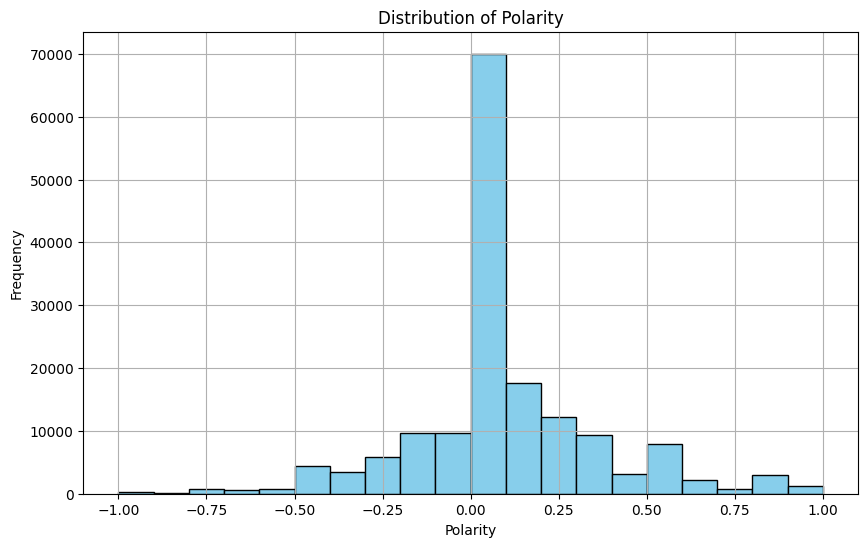

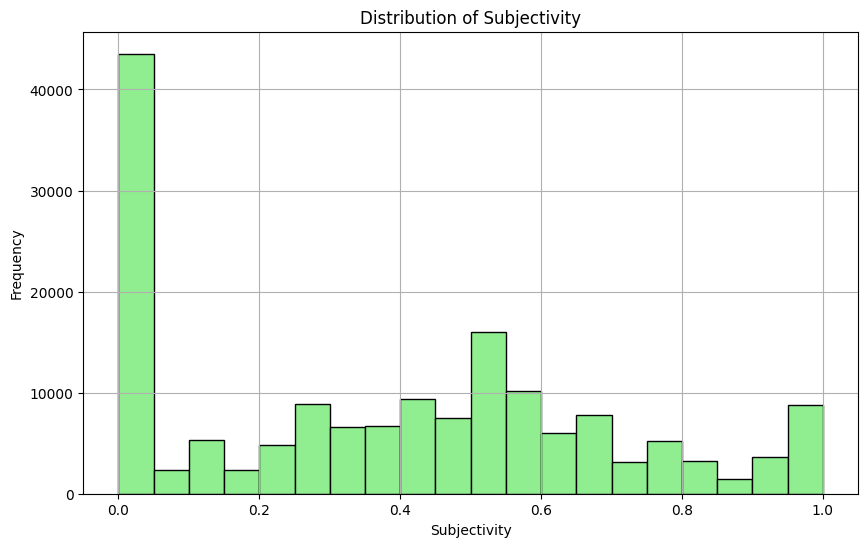

In [ ]:
# Plot Polarity
plt.figure(figsize=(10, 6))
plt.hist(data['polarity'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Polarity')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot Subjectivity
plt.figure(figsize=(10, 6))
plt.hist(data['subjectivity'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Subjectivity')
plt.xlabel('Subjectivity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
data['category'] = data['category'].replace({-1: 'negative', 0: 'neutral', 1: 'positive'})

In [ ]:
# Drop rows with missing values
data.dropna(subset=['clean_text', 'category'], inplace=True)

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.svm import SVC

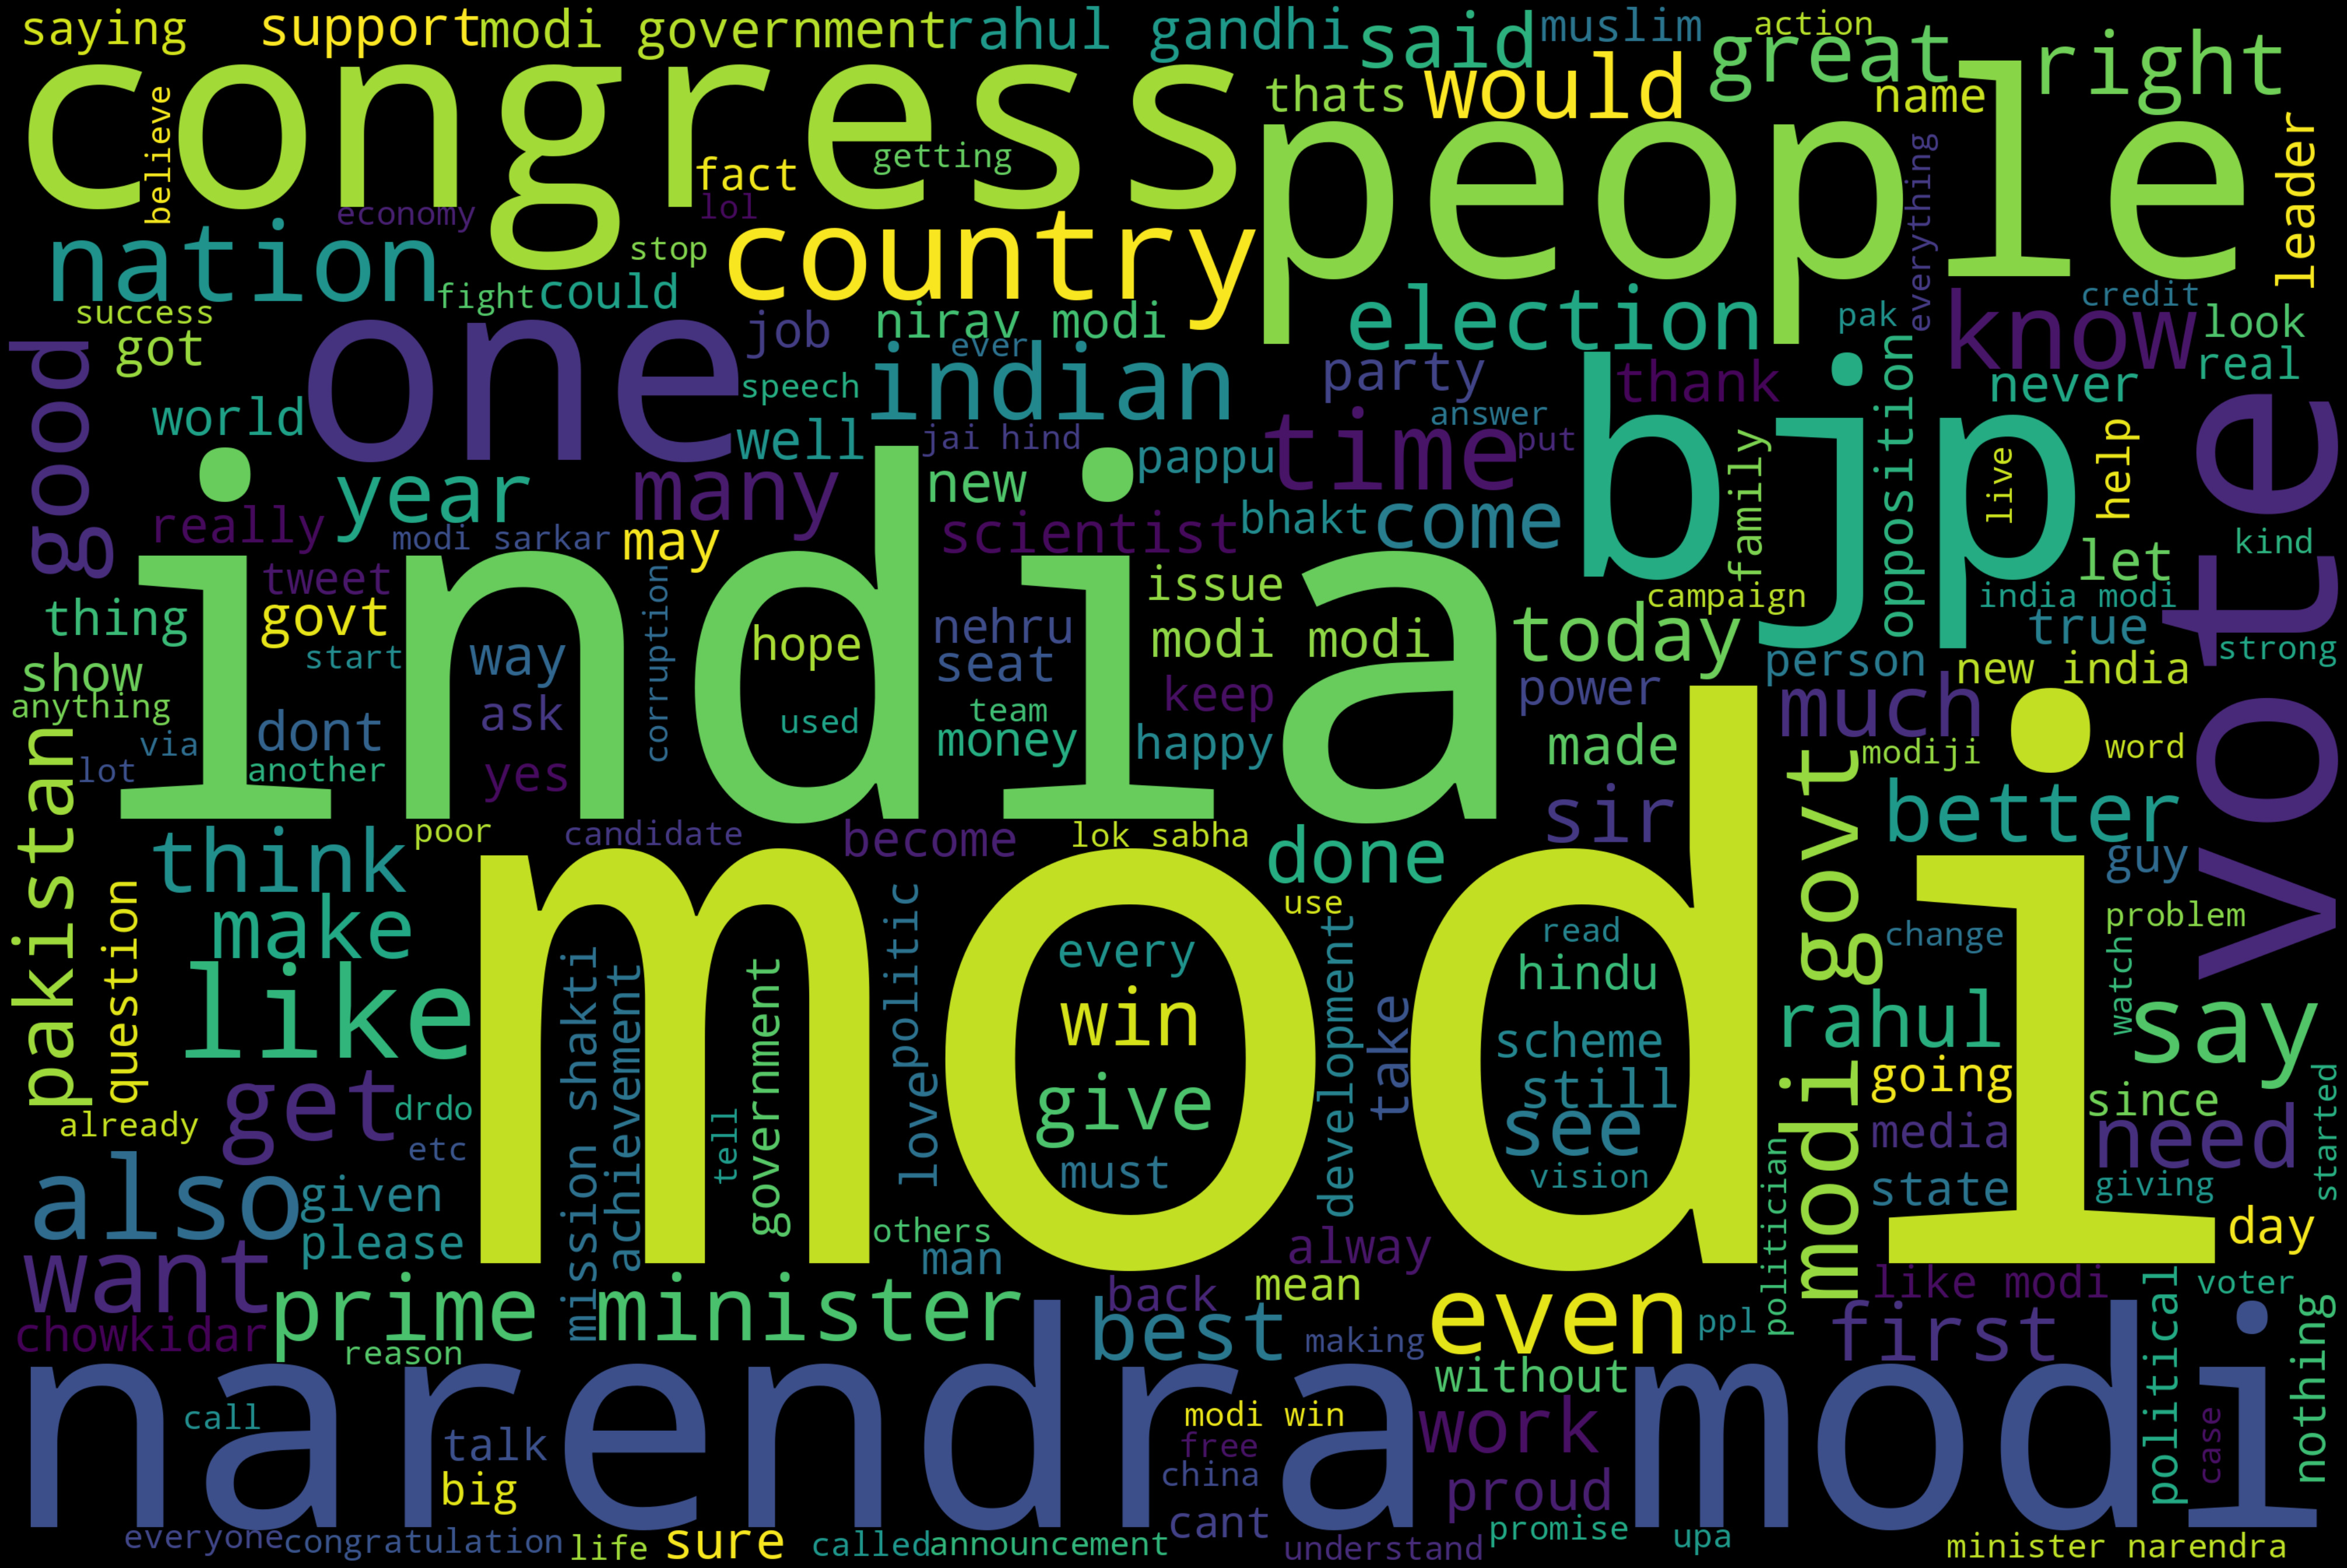

In [ ]:
text = ''

for tweet in data[data['category'] == "positive"]['clean_text']:
    text += f" {tweet}"

wordcloud = WordCloud(
width=3000, height=2000, background_color='black',
stopwords = set(nltk.corpus.stopwords.words("english"))).generate(text)

fig = plt.figure(figsize=(40,30), facecolor='k',edgecolor='k')

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show

del text


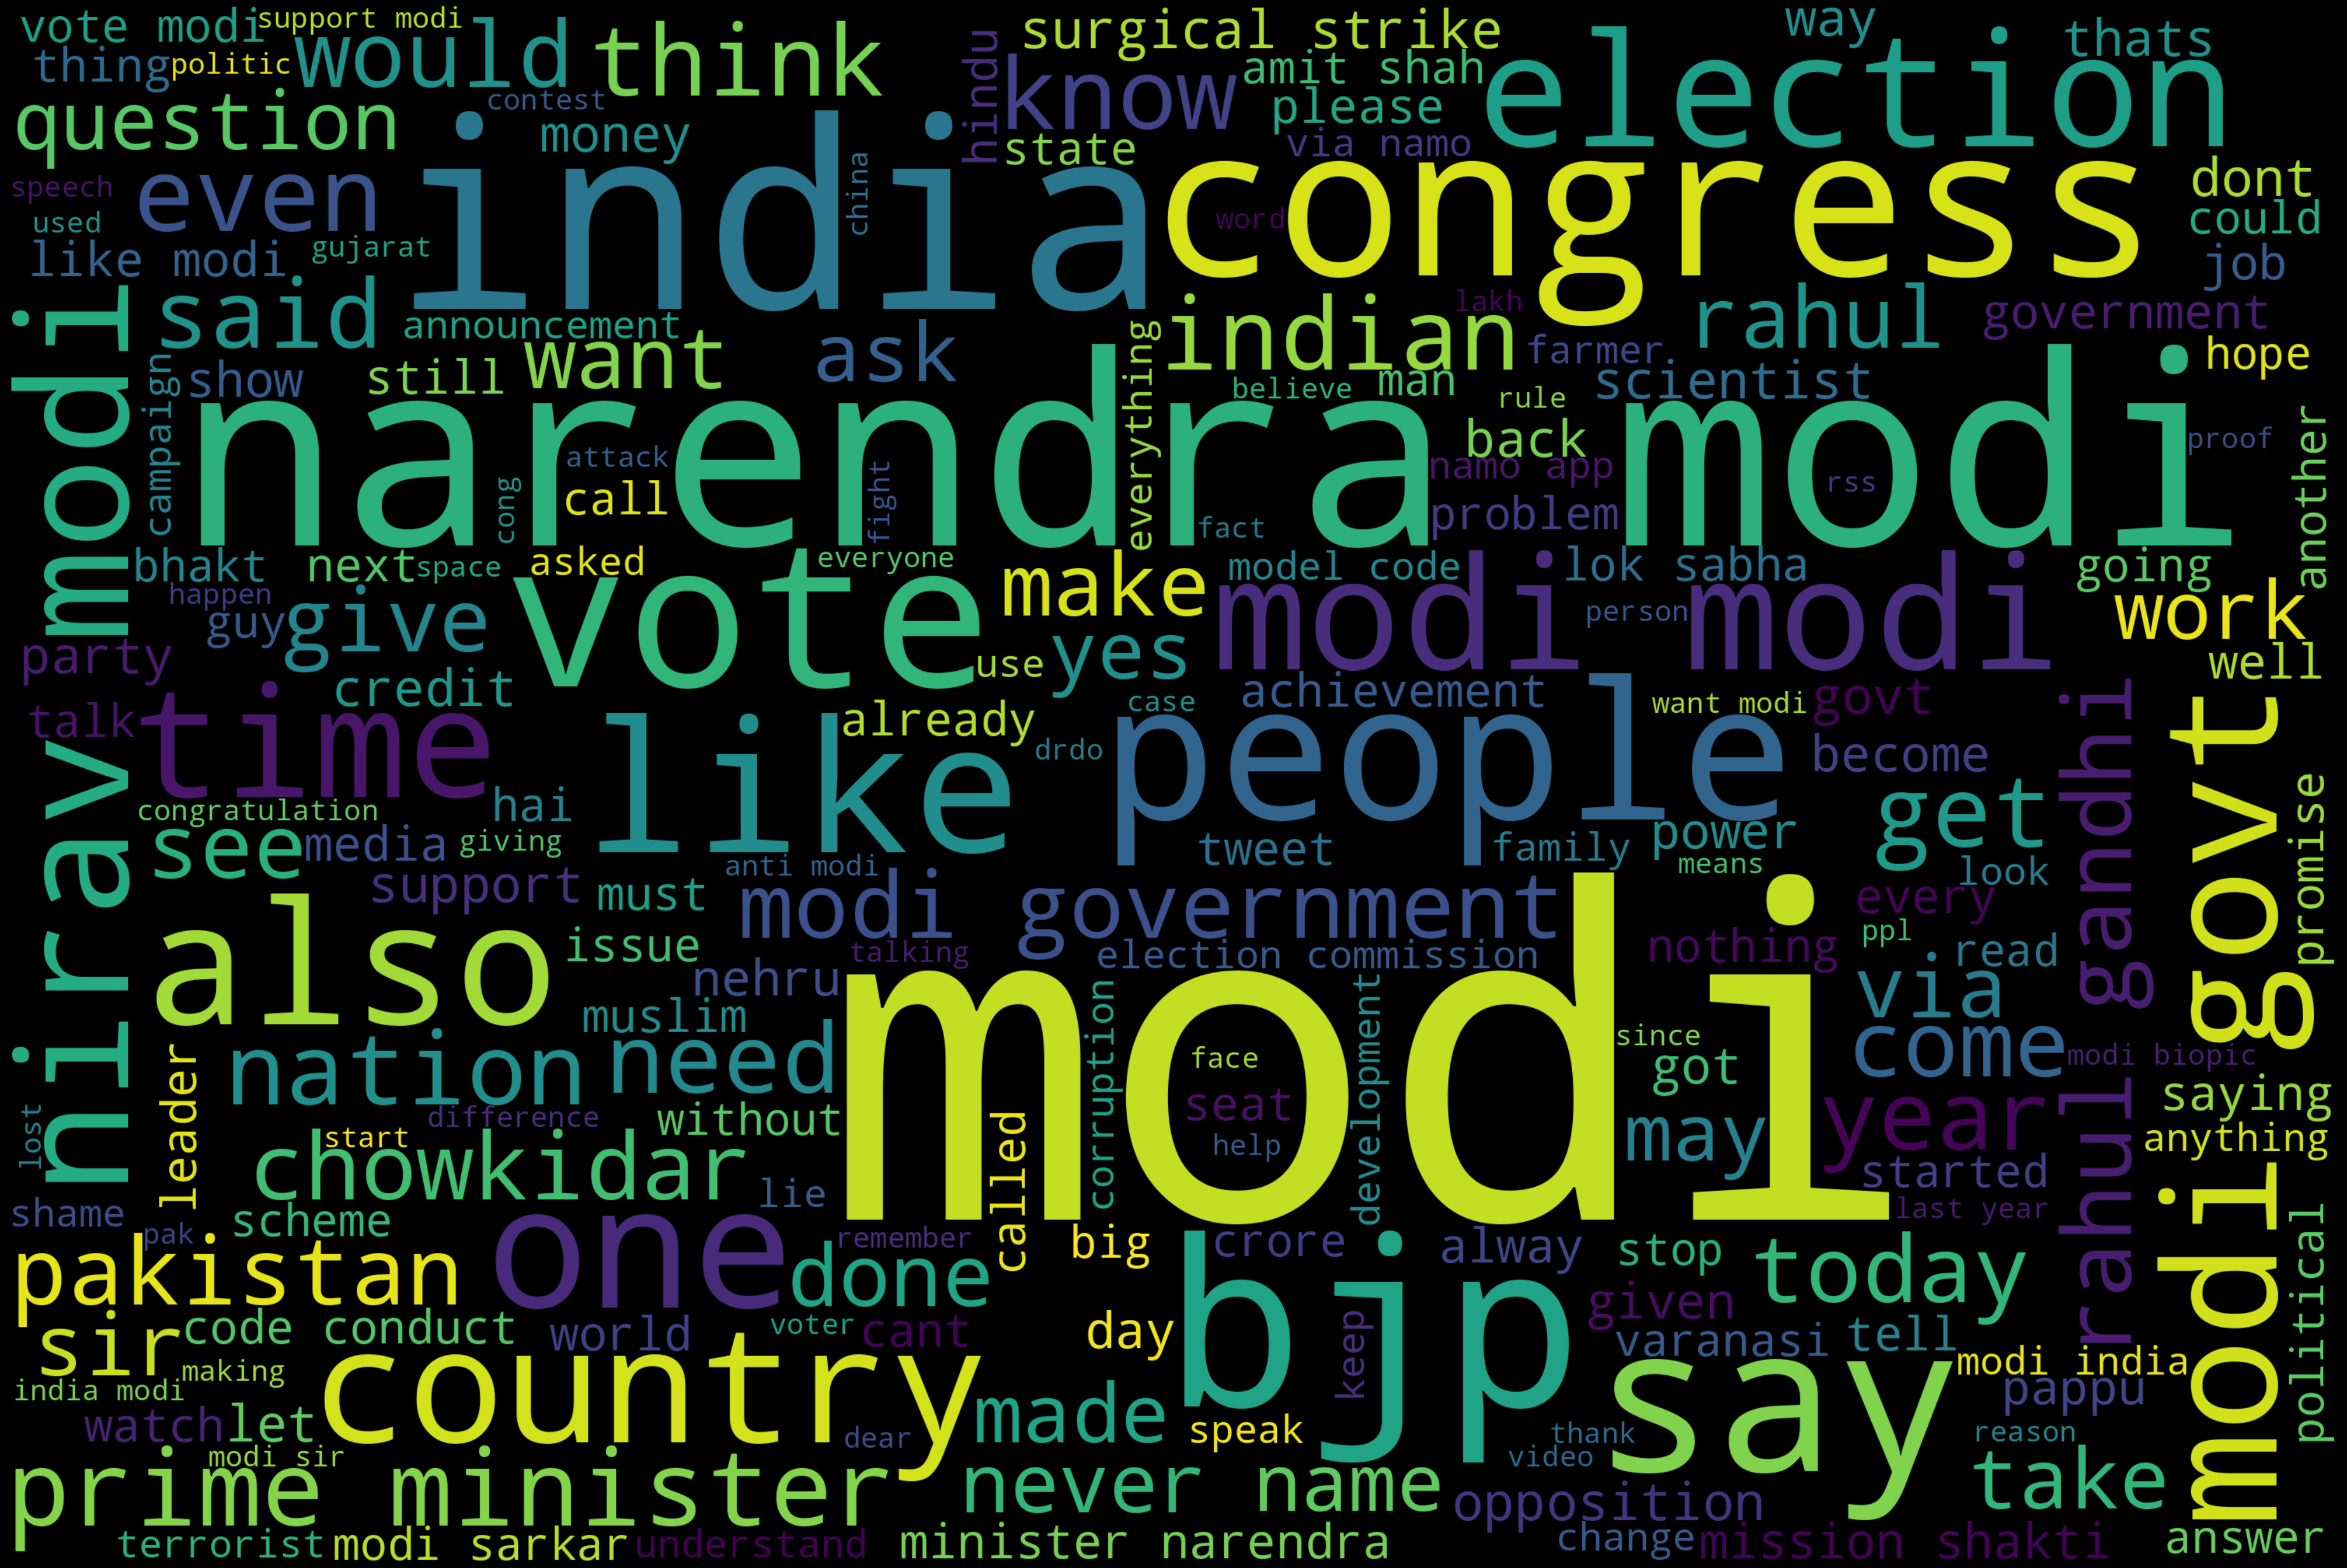

In [ ]:
text = ''

for tweet in data[data['category'] == "neutral"]['clean_text']:
    text += f" {tweet}"

wordcloud = WordCloud(
width=3000, height=2000, background_color='black',
stopwords = set(nltk.corpus.stopwords.words("english"))).generate(text)

fig = plt.figure(figsize=(40,30), facecolor='k',edgecolor='k')

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show

del text

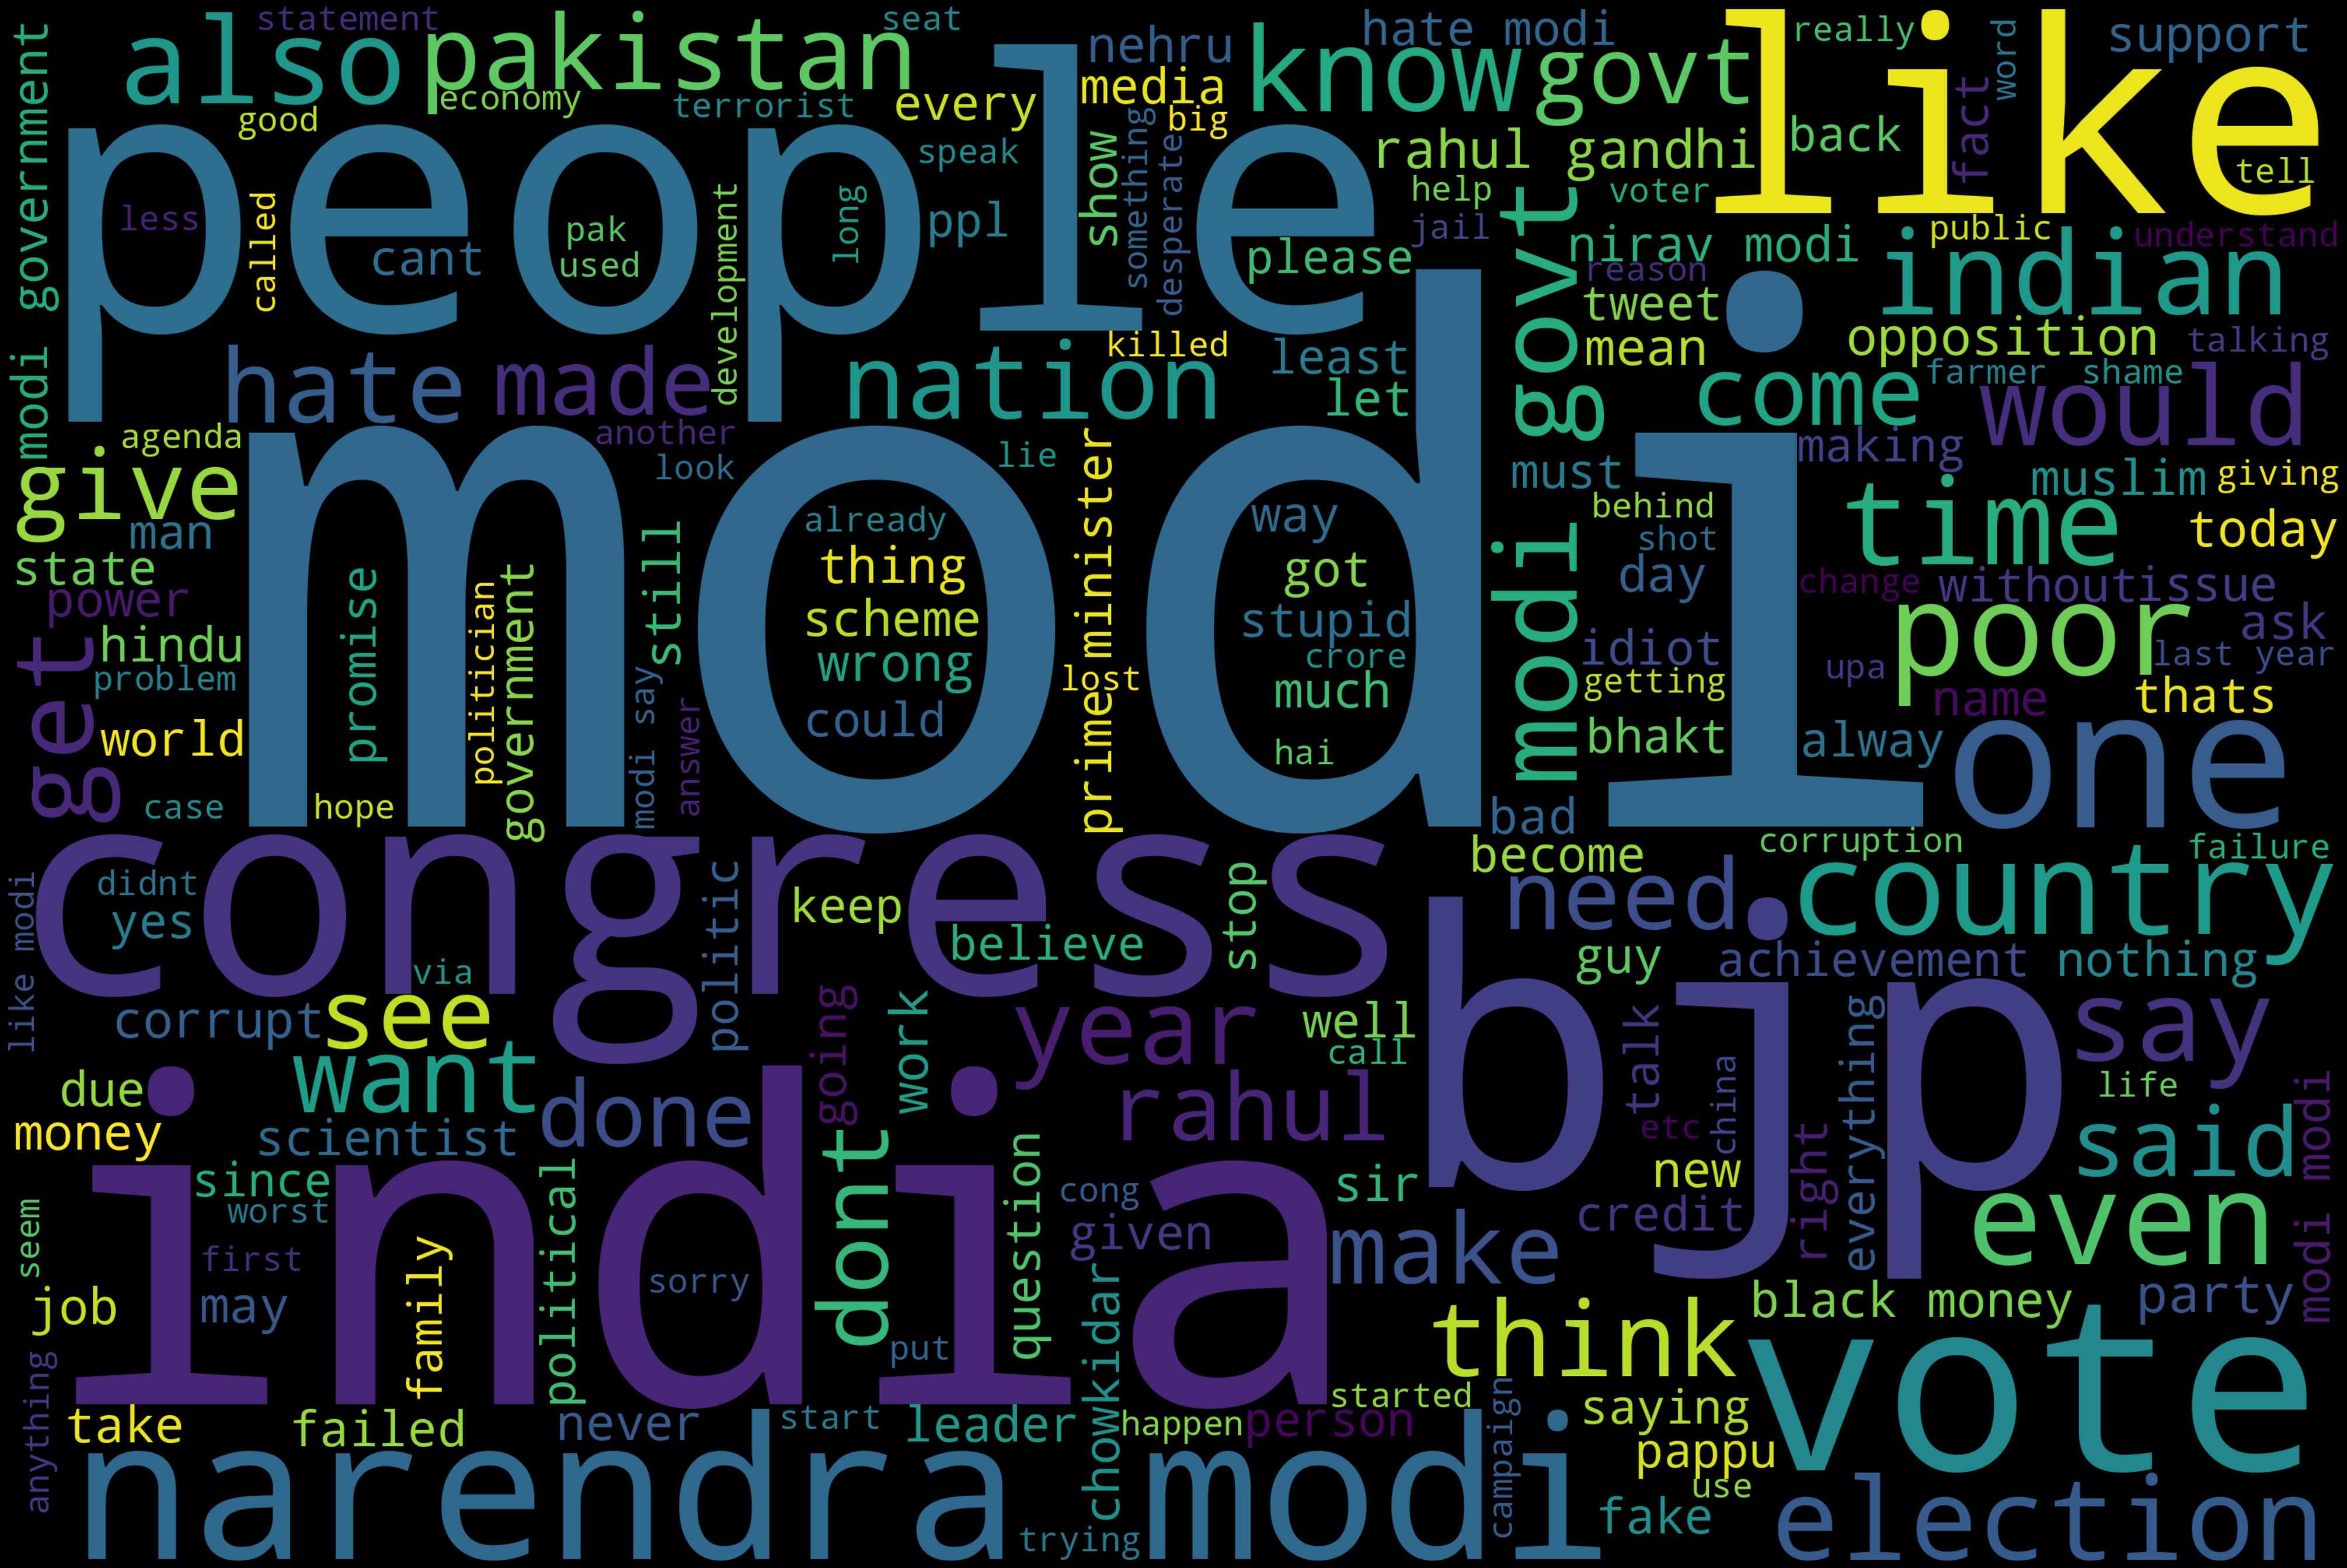

In [ ]:
text = ''

for tweet in data[data['category'] == "negative"]['clean_text']:
    text += f" {tweet}"

wordcloud = WordCloud(
width=3000, height=2000, background_color='black',
stopwords = set(nltk.corpus.stopwords.words("english"))).generate(text)

fig = plt.figure(figsize=(40,30), facecolor='k',edgecolor='k')

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show

del text

In [ ]:
# Display some stats
print(data['category'].value_counts())

category
positive    72250
neutral     55213
negative    35510
Name: count, dtype: int64


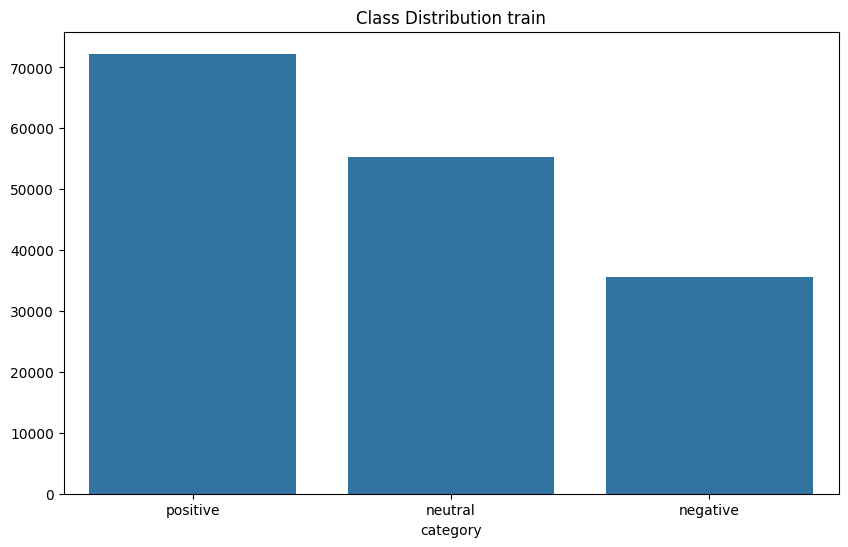

In [ ]:
dist = data['category'].value_counts()
def distribution_plot(x, y, name):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=x, y=y)
    plt.title(name)
    plt.show()

distribution_plot(x=dist.index, y=dist.values, name='Class Distribution train')

In [ ]:
#Using TF-IDF for text vectorization and logistic regression for model training
# Text Vectorization using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['clean_text'])

# Encode target labels (category) directly into numeric values
y = data['category'].map({'negative': 0, 'neutral': 1, 'positive': 2})

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)
print(y_pred, y_test)
# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[1 1 1 ... 2 2 2] 161520    1
95056     1
5215      1
33604     2
155301    2
         ..
95371     1
90726     2
87374     2
130773    2
45558     2
Name: category, Length: 32595, dtype: int64
Accuracy: 0.9254793680012272
F1 Score: 0.9246518862783125
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87      7230
           1       0.92      0.98      0.95     10961
           2       0.94      0.93      0.94     14404

    accuracy                           0.93     32595
   macro avg       0.92      0.91      0.92     32595
weighted avg       0.93      0.93      0.92     32595

Confusion Matrix:
 [[ 5981   494   755]
 [   96 10718   147]
 [  483   454 13467]]


In [ ]:
#Training the model with Naive Bayes
# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict on test set
y_pred_nb = nb.predict(X_test)

# Evaluate the classifier
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7430587513422304
Naive Bayes F1 Score: 0.730575638650299
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.42      0.58      7230
           1       0.88      0.68      0.77     10961
           2       0.66      0.95      0.78     14404

    accuracy                           0.74     32595
   macro avg       0.82      0.68      0.71     32595
weighted avg       0.79      0.74      0.73     32595

Naive Bayes Confusion Matrix:
 [[ 3061   546  3623]
 [   75  7445  3441]
 [  198   492 13714]]
